In [251]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots, cm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table
import seaborn as sns

from sklearn.svm import SVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay

### Conceptual

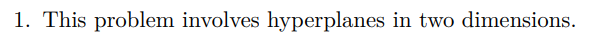

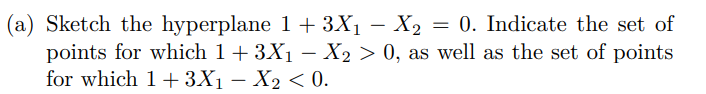

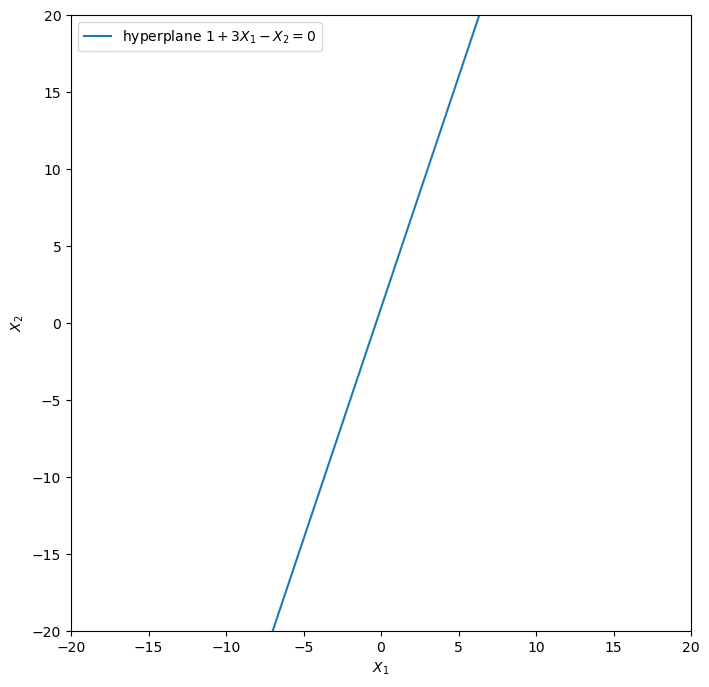

In [252]:
X_1 = np.linspace(-20, 20, 41)
X_2 = 1 + 3 * X_1

fig, ax = subplots(figsize=(8, 8))
ax.plot(X_1, X_2, label="hyperplane $1 + 3X_1 - X_2 = 0$")

ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.set_ylim(-20, 20)
ax.set_xlim(-20, 20)
ax.legend()

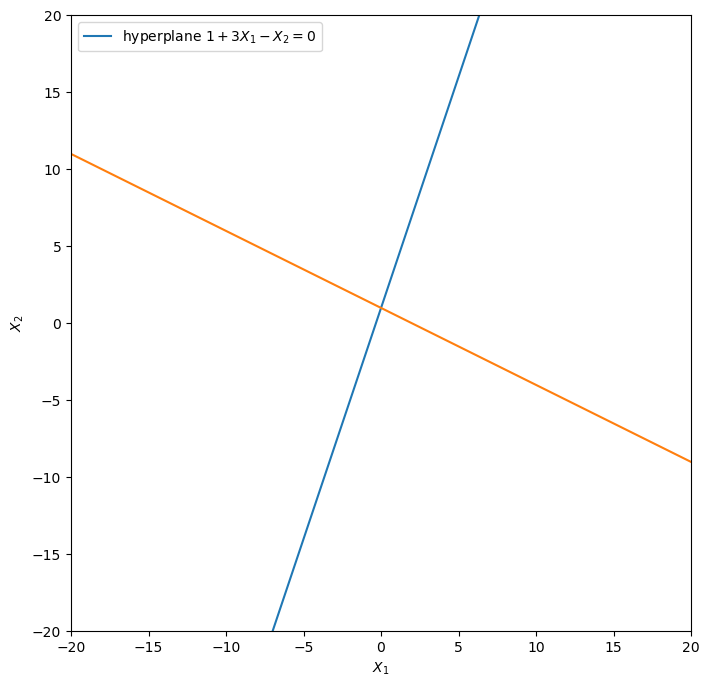

In [253]:
X_1 = np.linspace(-20, 20, 41)
X_2 = (-2  + X_1) / -2

ax.plot(X_1, X_2, label="hyperplane $-2 + X_1 + 2X_2 = 0$")

fig

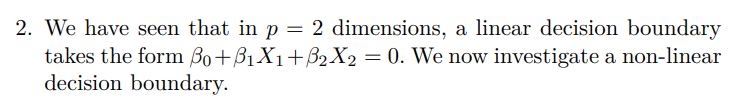

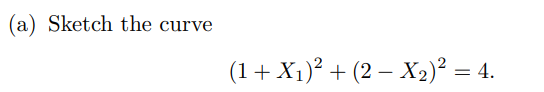

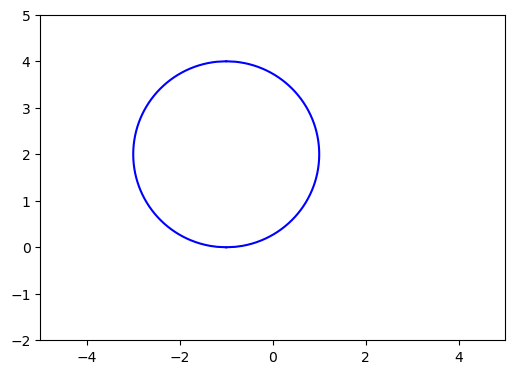

In [254]:
X_2 = np.linspace(0, 4, 400)
X_1_minus = -1 - np.sqrt(4 - (2 - X_2)**2)
X_1_plus = -1 + np.sqrt(4 - (2 - X_2)**2)

fig, ax = subplots(figsize=(6, 6))
ax.plot(X_1_minus, X_2, c="b")
ax.plot(X_1_plus, X_2, c="b")
ax.set_xlim(-5, 5)
ax.set_ylim(-2, 5)
ax.set_aspect("equal")

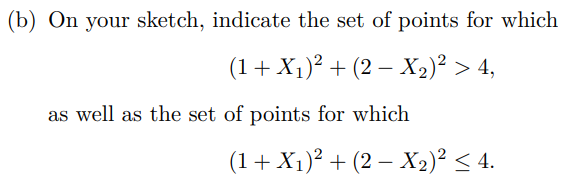

C:\Users\Admin\AppData\Local\Temp\ipykernel_17020\300627660.py:11: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contourf(X1, X2, expr, levels=[0, 4], colors=['lightcoral'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 < 4$')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17020\300627660.py:12: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contourf(X1, X2, expr, levels=[4, expr.max()], colors=['lightblue'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 > 4$')


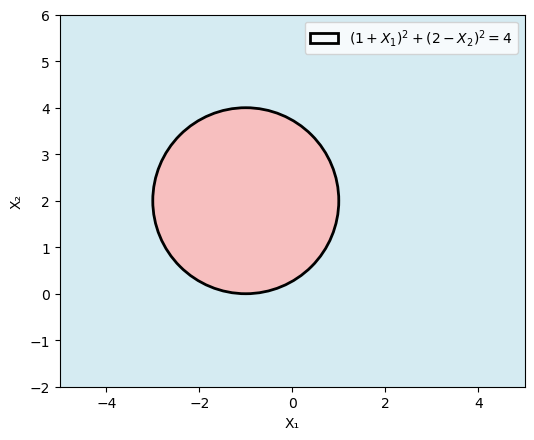

In [255]:
import matplotlib.pyplot as plt

x1 = np.linspace(-5, 5, 400)
x2 = np.linspace(-2, 6, 400)
X1, X2 = np.meshgrid(x1, x2)

expr = (1 + X1)**2 + (2 - X2)**2

fig, ax = plt.subplots(figsize=(6, 6))

ax.contourf(X1, X2, expr, levels=[0, 4], colors=['lightcoral'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 < 4$')
ax.contourf(X1, X2, expr, levels=[4, expr.max()], colors=['lightblue'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 > 4$')  
circle = plt.Circle((-1, 2), 2, color='k', fill=False, linewidth=2, label='$(1 + X_1)^2 + (2 - X_2)^2 = 4$')
ax.add_artist(circle)

ax.set_xlim(-5, 5)
ax.set_ylim(-2, 6)
ax.set_aspect('equal')

ax.set_xlabel('X₁')
ax.set_ylabel('X₂')
ax.legend()
plt.show()

In [256]:
X_test = [
  (0, 0),
  (-1, 1),
  (2, 2),
  (3, 8)
]

y_pred = []
for test_obs in X_test:
  X_1, X_2 = test_obs
  y_pred.append("blue" if (1 + X_1)**2 + (2 - X_2)**2 > 4 else "red")


In [257]:
y_pred

['blue', 'red', 'blue', 'blue']

C:\Users\Admin\AppData\Local\Temp\ipykernel_17020\1677276489.py:3: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contourf(X1, X2, expr, levels=[0, 4], colors=['lightcoral'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 < 4$')
C:\Users\Admin\AppData\Local\Temp\ipykernel_17020\1677276489.py:4: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contourf(X1, X2, expr, levels=[4, expr.max()], colors=['lightblue'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 > 4$')


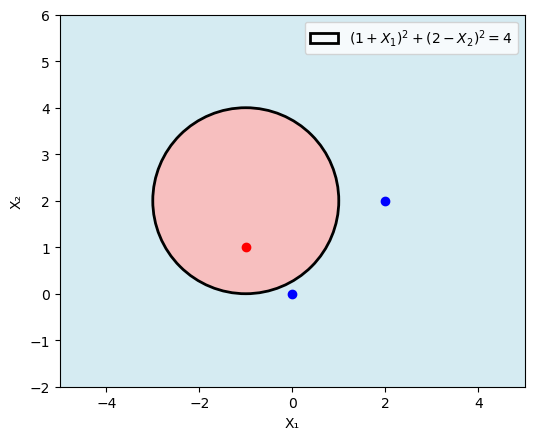

In [258]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.contourf(X1, X2, expr, levels=[0, 4], colors=['lightcoral'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 < 4$')
ax.contourf(X1, X2, expr, levels=[4, expr.max()], colors=['lightblue'], alpha=0.5, label='$(1 + X_1)^2 + (2 - X_2)^2 > 4$')  
circle = plt.Circle((-1, 2), 2, color='k', fill=False, linewidth=2, label='$(1 + X_1)^2 + (2 - X_2)^2 = 4$')
ax.add_artist(circle)

ax.set_xlim(-5, 5)
ax.set_ylim(-2, 6)
ax.set_aspect('equal')

for idx, test_obs in enumerate(X_test):
  ax.scatter(test_obs[0], test_obs[1], c=y_pred[idx])

ax.set_xlabel('X₁')
ax.set_ylabel('X₂')
ax.legend()
plt.show()

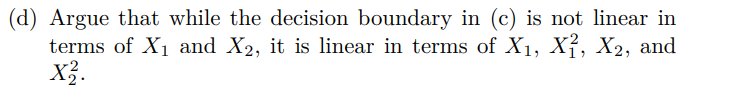

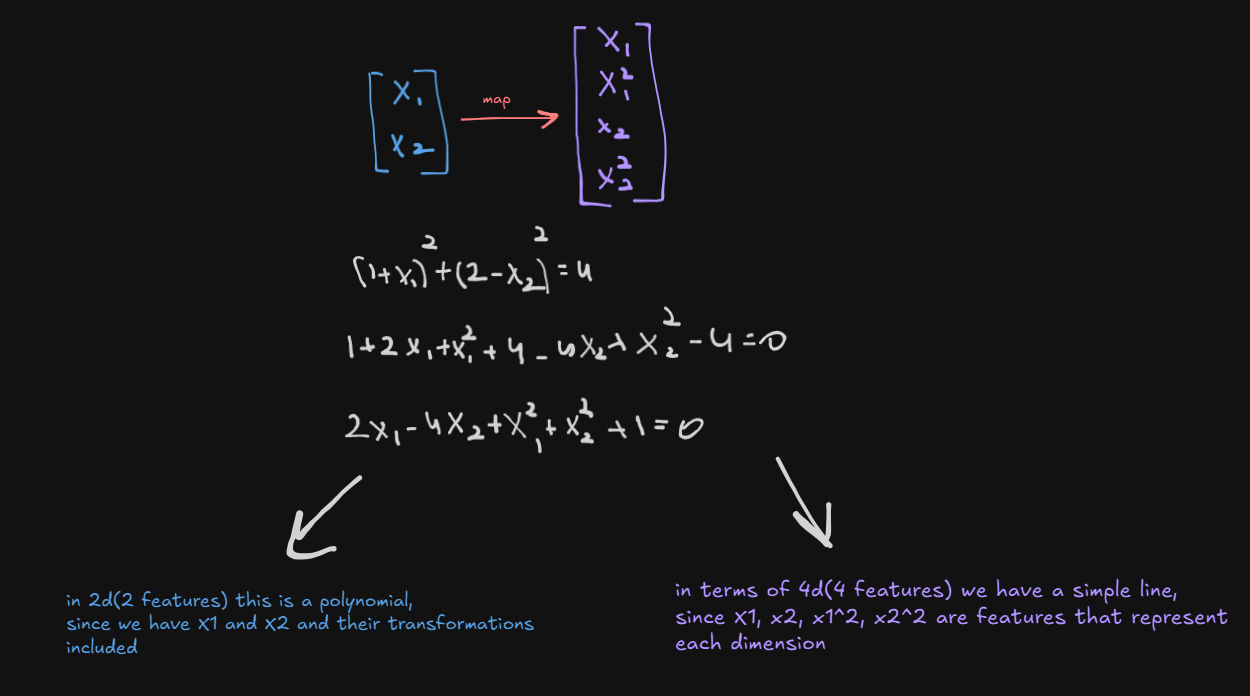

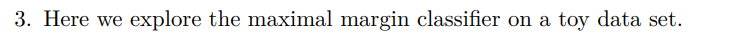

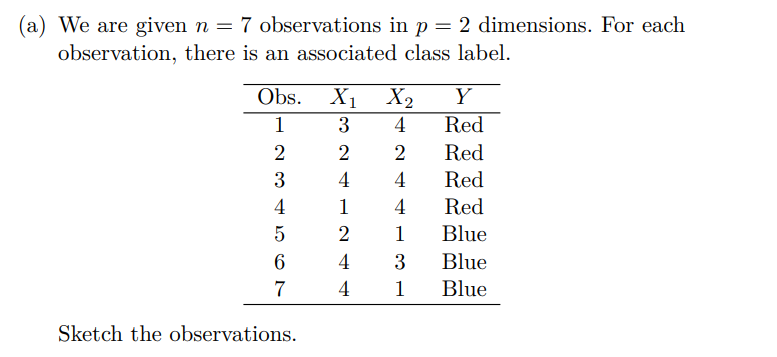

In [259]:
data = pd.DataFrame({
  "x1": [3, 2, 4, 1, 2, 4, 4],
  "x2": [4, 2, 4, 4, 1, 3, 1],
  "y": ["red", "red", "red", "red", "blue", "blue", "blue"]  
})
data

,x1,x2,y
0,3,4,red
1,2,2,red
2,4,4,red
3,1,4,red
4,2,1,blue
5,4,3,blue
6,4,1,blue


Text(0.5, 0, '$X_2$')

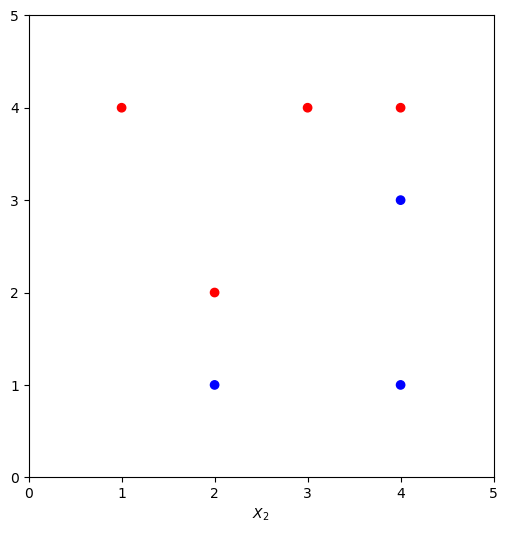

In [260]:
fig, ax = subplots(figsize=(6, 6))
plt.scatter(data["x1"],
            data["x2"],
            c=data["y"])
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_xlabel("$X_1$")
ax.set_xlabel("$X_2$")

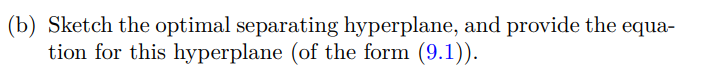

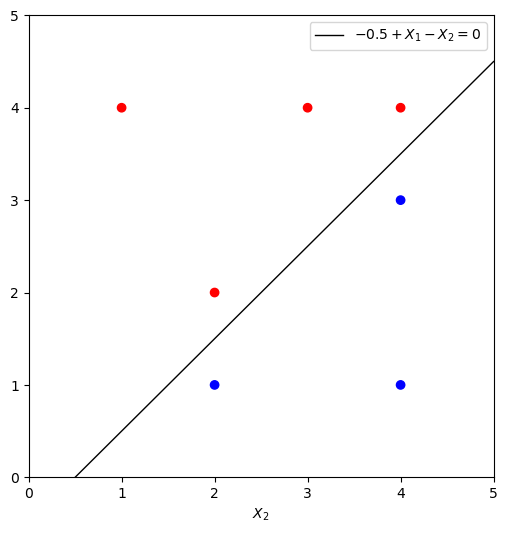

In [261]:
X_1 = np.linspace(0, 5, 100)
X_2 = -0.5 + X_1

ax.plot(X_1, X_2, c="black", linewidth=1, label="$-0.5 + X_1 - X_2 = 0$")
ax.legend()

fig

hyperplane:
$$-0.5 + X_1 - X_2 = 0$$

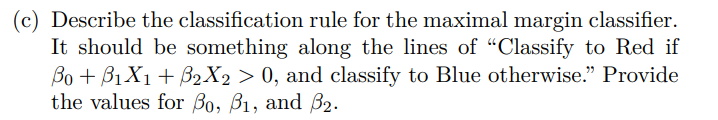

So, we have an equation of hyperplane:
$$\beta_0 + \beta_1X_1 - \beta_2X_2 = 0$$
$$-0.5 + X_1 - X_2 = 0$$
where:
- $\beta_0$ = -0.5
- $\beta_1$ = 1
- $\beta_2$ = 1

We have two classes: "red": 1 and "blue": 0

If observation is above hyperplane or mathematically:
$$-0.5 + X_1 - X_2 > 0$$
then observation will be classified as "red"
or if
$$-0.5 + X_1 - X_2 < 0$$
then observation will be classifed as "blue"


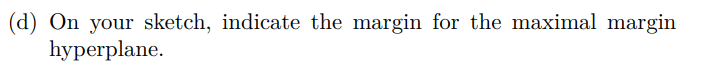

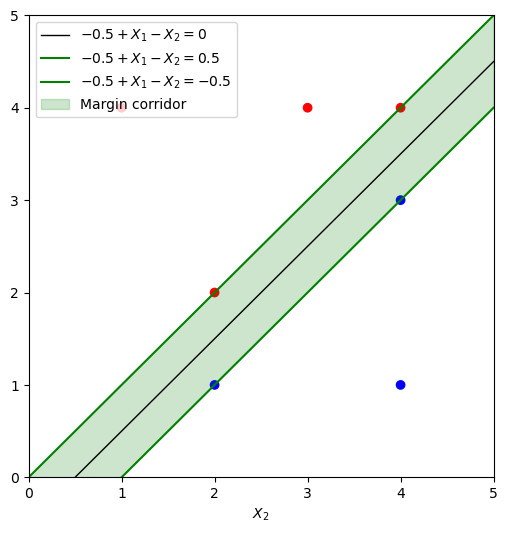

In [262]:
X_1 = np.linspace(0, 5, 100)
X_2 = -0.5 + X_1

lower = X_2 + 0.5
upper = X_2 - 0.5

ax.plot(X_1, upper, c="green", label="$-0.5 + X_1 - X_2 = 0.5$")
ax.plot(X_1, lower, c="green", label="$-0.5 + X_1 - X_2 = -0.5$")

ax.fill_between(X_1, lower, upper, color="green", alpha=0.2, label="Margin corridor")

ax.legend()
fig

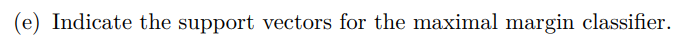

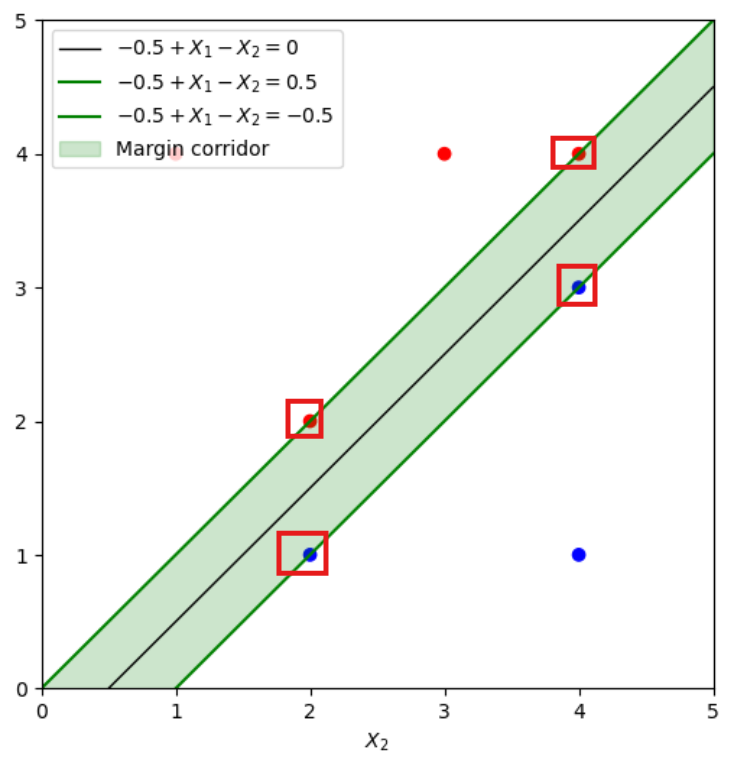

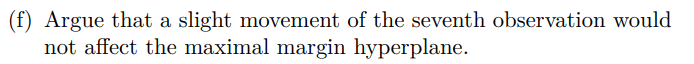

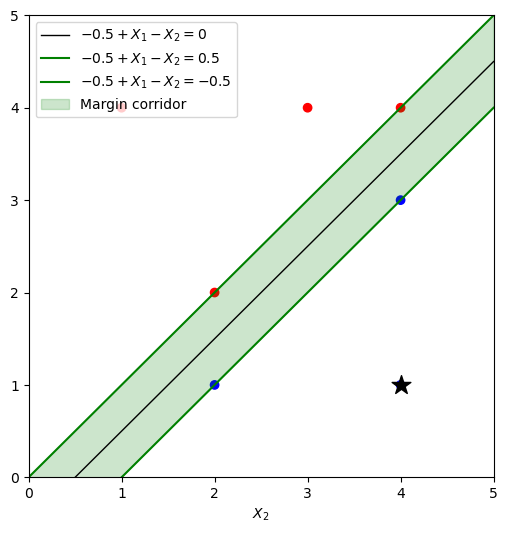

In [263]:
obs = data.iloc[-1]
ax.scatter(obs["x1"], obs["x2"], c="black", marker="*", s=200, label="observation")
fig

Here we see, that seventh observation is not a support vector, and from thery we know, that very crucial feature of maximal margin classifier(and as consequence in SVC and SVM): only support vectors can affect the hyperplane

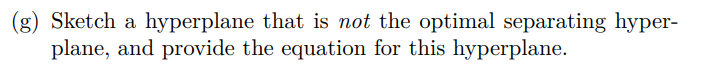

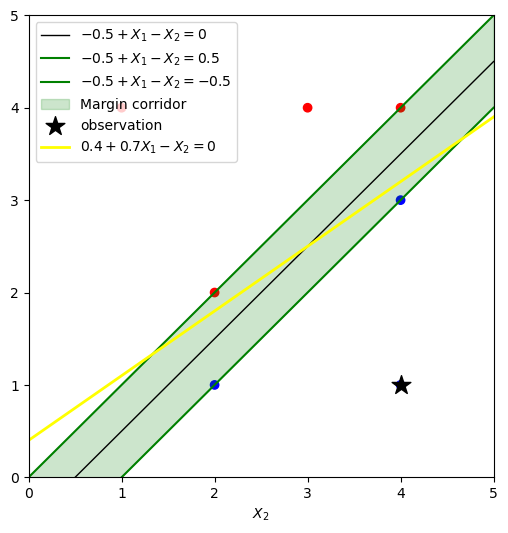

In [264]:
X_1 = np.linspace(0, 5, 100)
X_2 = 0.4 + 0.7 * X_1

ax.plot(X_1, X_2, c="yellow", linewidth=2, label="$0.4 + 0.7X_1 - X_2 = 0$")

ax.legend()
fig

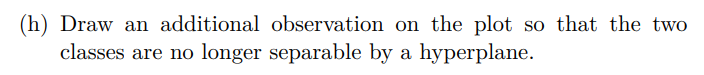

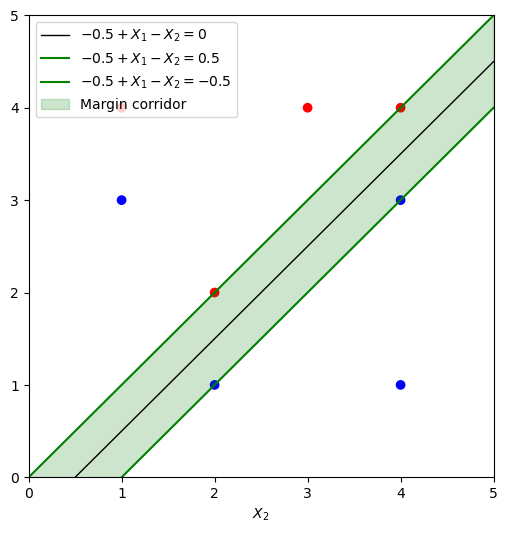

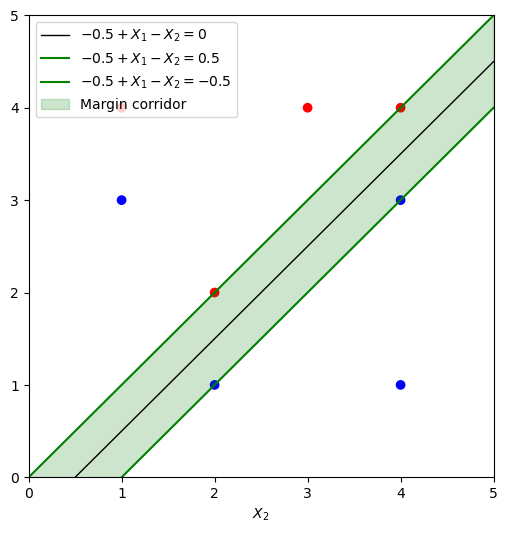

In [265]:
data.loc[len(data)] = [1, 3, "blue"]

fig, ax = subplots(figsize=(6, 6))
plt.scatter(data["x1"],
            data["x2"],
            c=data["y"])
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.set_xlabel("$X_1$")
ax.set_xlabel("$X_2$")

X_1 = np.linspace(0, 5, 100)
X_2 = -0.5 + X_1

ax.plot(X_1, X_2, c="black", linewidth=1, label="$-0.5 + X_1 - X_2 = 0$")
ax.legend()

lower = X_2 + 0.5
upper = X_2 - 0.5

ax.plot(X_1, upper, c="green", label="$-0.5 + X_1 - X_2 = 0.5$")
ax.plot(X_1, lower, c="green", label="$-0.5 + X_1 - X_2 = -0.5$")

ax.fill_between(X_1, lower, upper, color="green", alpha=0.2, label="Margin corridor")

ax.legend()
fig

### Applied

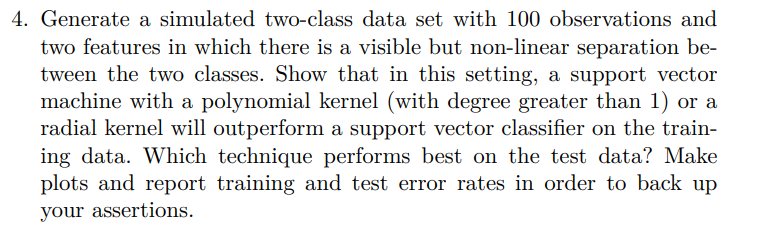

In [292]:
rng = np.random.default_rng(0)
X = rng.standard_normal((100, 2))
X.shape

(100, 2)

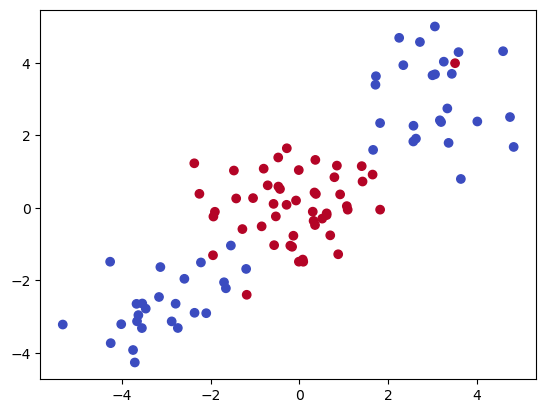

In [293]:
X[:25] -= 3
X[25:51] +=3
y = np.array([-1] * 50 + [1] * 50)

plt.scatter(X[:, 0],
           X[:, 1],
           c=y,
           cmap=cm.coolwarm)

In [295]:
X_train, X_test, y_train, y_test = skm.train_test_split(X, y, test_size=0.2, random_state=42)

Truth,-1,1
Predicted,,
-1,0,0
1,12,8


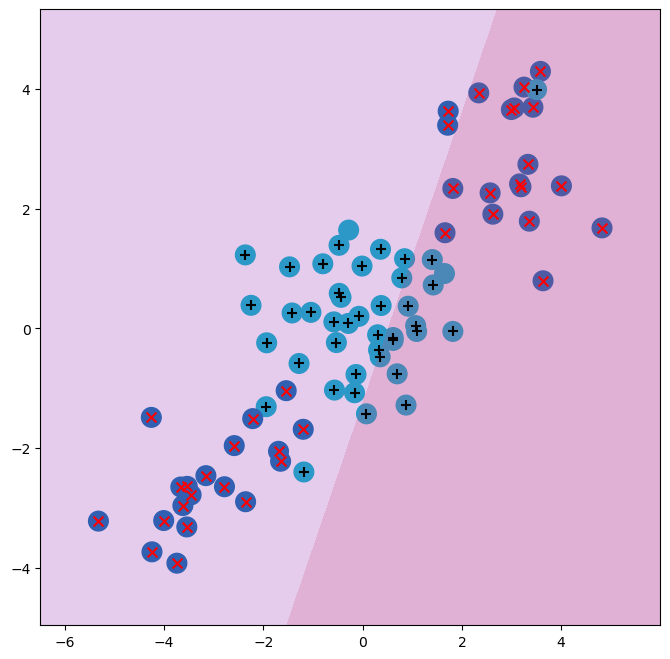

In [ ]:
linear_svm = SVC(kernel="linear")
linear_svm.fit(X_train, y_train)

fig, ax = subplots(figsize=(8, 8))
plot_svm(X_train,
         y_train,
         linear_svm,
         ax=ax)

y_pred = linear_svm.predict(X_test)

confusion_table(y_pred, y_test)

In [296]:
kfold = skm.KFold(n_splits=5,
                  random_state=0,
                  shuffle=True)

param_grid = {
  "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid = skm.GridSearchCV(linear_svm,
                        param_grid=param_grid,
                        cv=kfold,
                        scoring="accuracy",
                        refit=True)

grid.fit(X_train, y_train)
grid.best_params_

{'C': 1}

Truth,-1,1
Predicted,,
-1,0,0
1,12,8


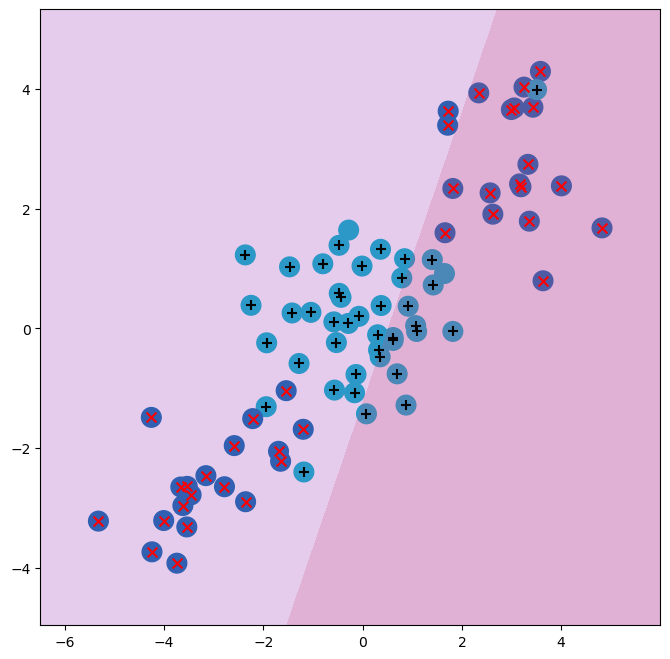

In [300]:
best_linear_svm = grid.best_estimator_

fig, ax = subplots(figsize=(8, 8))
plot_svm(X_train,
         y_train,
         best_linear_svm,
         ax=ax)

y_pred = best_linear_svm.predict(X_test)
confusion_table(y_pred, y_test) 

In [301]:
# add svm with polynomial kernel and etc